In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("survey_results.csv")

In [8]:
df.head(3)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30010 entries, 0 to 30009
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   respondent_id                   30010 non-null  object
 1   age                             30010 non-null  int64 
 2   gender                          30010 non-null  object
 3   zone                            30010 non-null  object
 4   occupation                      30010 non-null  object
 5   income_levels                   21946 non-null  object
 6   consume_frequency(weekly)       30002 non-null  object
 7   current_brand                   30010 non-null  object
 8   preferable_consumption_size     30010 non-null  object
 9   awareness_of_other_brands       30010 non-null  object
 10  reasons_for_choosing_brands     30010 non-null  object
 11  flavor_preference               30010 non-null  object
 12  purchase_channel                30000 non-null

In [10]:
df.isnull().sum()

respondent_id                        0
age                                  0
gender                               0
zone                                 0
occupation                           0
income_levels                     8064
consume_frequency(weekly)            8
current_brand                        0
preferable_consumption_size          0
awareness_of_other_brands            0
reasons_for_choosing_brands          0
flavor_preference                    0
purchase_channel                    10
packaging_preference                 0
health_concerns                      0
typical_consumption_situations       0
price_range                          0
dtype: int64

In [11]:
# Treatment of Null Values
df.duplicated().sum()

10

In [12]:
df[df.duplicated()].count()

respondent_id                     10
age                               10
gender                            10
zone                              10
occupation                        10
income_levels                      7
consume_frequency(weekly)         10
current_brand                     10
preferable_consumption_size       10
awareness_of_other_brands         10
reasons_for_choosing_brands       10
flavor_preference                 10
purchase_channel                  10
packaging_preference              10
health_concerns                   10
typical_consumption_situations    10
price_range                       10
dtype: int64

In [13]:
df[df.duplicated()]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
2309,R02309,27,M,Urban,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Traditional,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),150-200
2666,R02665,61,M,Metro,Entrepreneur,16L - 25L,3-4 times,Established,Medium (500 ml),above 4,Brand Reputation,Exotic,Retail Store,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",200-250
5151,R05149,21,M,Semi-Urban,Student,NaN,3-4 times,Established,Small (250 ml),2 to 4,Availability,Traditional,Retail Store,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
7794,R07791,25,M,Metro,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
8516,R08512,20,F,Metro,Student,NaN,5-7 times,Established,Large (1 L),0 to 1,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
11317,R11312,18,F,Urban,Student,NaN,0-2 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Premium,Medium (Moderately health-conscious),Social (eg. Parties),100-150
19050,R19044,57,M,Semi-Urban,Retired,<10L,3-4 times,Newcomer,Large (1 L),2 to 4,Price,Traditional,Retail Store,Premium,High (Very health-conscious),Social (eg. Parties),150-200
22412,R22405,26,M,Metro,Working Professional,16L - 25L,0-2 times,Newcomer,Small (250 ml),0 to 1,Price,Exotic,Online,Premium,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
23406,R23398,27,M,Urban,Working Professional,10L - 15L,5-7 times,Newcomer,Large (1 L),above 4,Availability,Traditional,Online,Premium,High (Very health-conscious),Casual (eg. At home),200-250
25068,R25059,34,F,Urban,Working Professional,16L - 25L,0-2 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Exotic,Online,Eco-Friendly,High (Very health-conscious),"Active (eg. Sports, gym)",150-200


In [14]:
df_new = df.drop_duplicates()

In [15]:
df_new[df_new.duplicated()]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range


In [16]:
df_new.describe()

,age
count,30000.000000
mean,33.048167
std,13.438904
min,18.000000
25%,23.000000
50%,31.000000
75%,40.000000
max,604.000000


In [17]:
df_new.age.max()

604

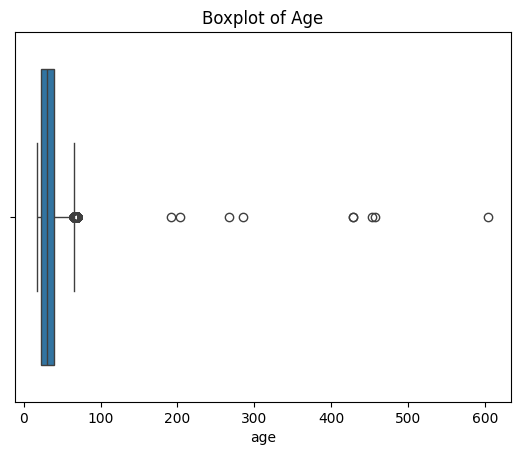

In [18]:
# Outlier handling
sns.boxplot(x=df_new['age'])
plt.title('Boxplot of Age')
plt.show()

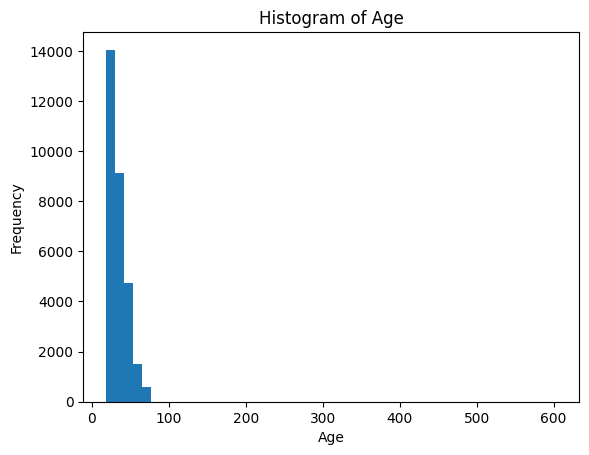

In [19]:
plt.hist(df_new['age'],bins = 50)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [20]:
Q1 = df_new['age'].quantile(0.25)
Q3 = df_new['age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_no_outliers = df_new[(df_new['age'] >= lower) & (df_new['age'] <= upper)]

In [21]:
print("Original:", df_new.shape)
print("After removing outliers:", df_no_outliers.shape)

Original: (30000, 17)
After removing outliers: (29507, 17)


In [22]:
df_no_outliers.describe()

,age
count,29507.000000
mean,32.373132
std,11.117786
min,18.000000
25%,23.000000
50%,30.000000
75%,40.000000
max,65.000000


In [23]:
df_new[df_new.age >75].count()

respondent_id                     9
age                               9
gender                            9
zone                              9
occupation                        9
income_levels                     8
consume_frequency(weekly)         9
current_brand                     9
preferable_consumption_size       9
awareness_of_other_brands         9
reasons_for_choosing_brands       9
flavor_preference                 9
purchase_channel                  9
packaging_preference              9
health_concerns                   9
typical_consumption_situations    9
price_range                       9
dtype: int64

#### If we use the IQR method to remove outliers, we would lose 493 rows from the dataset. However, if we instead cap the maximum age at 75, only 9 records are removed, which seems more appropriate since ages above 75 appear unrealistic.

In [24]:
df_new_1 = df_new[df_new.age <=75]

In [25]:
df_new_1.isnull().sum()

respondent_id                        0
age                                  0
gender                               0
zone                                 0
occupation                           0
income_levels                     8060
consume_frequency(weekly)            8
current_brand                        0
preferable_consumption_size          0
awareness_of_other_brands            0
reasons_for_choosing_brands          0
flavor_preference                    0
purchase_channel                    10
packaging_preference                 0
health_concerns                      0
typical_consumption_situations       0
price_range                          0
dtype: int64

In [26]:
df_new_1['consume_frequency(weekly)'].head()

0    3-4 times
1    5-7 times
2    3-4 times
3    5-7 times
4    3-4 times
Name: consume_frequency(weekly), dtype: object

In [27]:
df_new_1['consume_frequency(weekly)'].mode()[0]

'3-4 times'

In [28]:
df_new_1['consume_frequency(weekly)'].fillna(df_new_1['consume_frequency(weekly)'].mode()[0],inplace=True)

C:\Users\Ashok\AppData\Local\Temp\ipykernel_27868\130280086.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new_1['consume_frequency(weekly)'].fillna(df_new_1['consume_frequency(weekly)'].mode()[0],inplace=True)
C:\Users\Ashok\AppData\Local\Temp\ipykernel_27868\130280086.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_1['cons

In [29]:
df_new_1['consume_frequency(weekly)'].isnull().sum()

0

In [30]:
df_new_1.isnull().sum()

respondent_id                        0
age                                  0
gender                               0
zone                                 0
occupation                           0
income_levels                     8060
consume_frequency(weekly)            0
current_brand                        0
preferable_consumption_size          0
awareness_of_other_brands            0
reasons_for_choosing_brands          0
flavor_preference                    0
purchase_channel                    10
packaging_preference                 0
health_concerns                      0
typical_consumption_situations       0
price_range                          0
dtype: int64

In [31]:
df_new_1.income_levels.unique()

array(['<10L', '> 35L', '16L - 25L', nan, '10L - 15L', '26L - 35L'],
      dtype=object)

In [32]:
df_new_1['income_levels'] = df_new_1['income_levels'].fillna('Not Known')

C:\Users\Ashok\AppData\Local\Temp\ipykernel_27868\436616098.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_1['income_levels'] = df_new_1['income_levels'].fillna('Not Known')


In [33]:
df_new_1['income_levels'].isnull().sum()

0

In [34]:
df_new_1.income_levels.unique()

array(['<10L', '> 35L', '16L - 25L', 'Not Known', '10L - 15L',
       '26L - 35L'], dtype=object)

In [35]:
df_new_1.isnull().sum()

respondent_id                      0
age                                0
gender                             0
zone                               0
occupation                         0
income_levels                      0
consume_frequency(weekly)          0
current_brand                      0
preferable_consumption_size        0
awareness_of_other_brands          0
reasons_for_choosing_brands        0
flavor_preference                  0
purchase_channel                  10
packaging_preference               0
health_concerns                    0
typical_consumption_situations     0
price_range                        0
dtype: int64

In [36]:
df_new_1.purchase_channel.unique()

array(['Online', 'Retail Store', nan], dtype=object)

In [37]:
df_new_1['purchase_channel'] = df_new_1['purchase_channel'].fillna('Not Specified')

C:\Users\Ashok\AppData\Local\Temp\ipykernel_27868\3367276648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_1['purchase_channel'] = df_new_1['purchase_channel'].fillna('Not Specified')


In [38]:
df_new_1.isnull().sum()

respondent_id                     0
age                               0
gender                            0
zone                              0
occupation                        0
income_levels                     0
consume_frequency(weekly)         0
current_brand                     0
preferable_consumption_size       0
awareness_of_other_brands         0
reasons_for_choosing_brands       0
flavor_preference                 0
purchase_channel                  0
packaging_preference              0
health_concerns                   0
typical_consumption_situations    0
price_range                       0
dtype: int64

In [39]:
df_new_1.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,Not Known,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100


In [40]:
for col in df_new_1.columns:
    
    print(col,":", df_new_1[col].unique())

respondent_id : ['R00001' 'R00002' 'R00003' ... 'R29998' 'R29999' 'R30000']
age : [30 46 41 33 23 22 45 31 27 49 44 19 24 32 56 54 37 63 52 40 35 21 34 26
 18 20 25 39 53 28 59 36 50 29 43 42 38 70 51 68 48 62 60 65 47 67 64 55
 66 57 61 69 58]
gender : ['M' 'F']
zone : ['Urban' 'Metro' 'Rural' 'Semi-Urban' 'Metor' 'urbna']
occupation : ['Working Professional' 'Student' 'Entrepreneur' 'Retired']
income_levels : ['<10L' '> 35L' '16L - 25L' 'Not Known' '10L - 15L' '26L - 35L']
consume_frequency(weekly) : ['3-4 times' '5-7 times' '0-2 times']
current_brand : ['Newcomer' 'Established' 'newcomer' 'Establishd']
preferable_consumption_size : ['Medium (500 ml)' 'Large (1 L)' 'Small (250 ml)']
awareness_of_other_brands : ['0 to 1' '2 to 4' 'above 4']
reasons_for_choosing_brands : ['Price' 'Quality' 'Availability' 'Brand Reputation']
flavor_preference : ['Traditional' 'Exotic']
purchase_channel : ['Online' 'Retail Store' 'Not Specified']
packaging_preference : ['Simple' 'Premium' 'Eco-Friendly']

#### zone , current_brand columns have misspelling of categorical values

In [41]:
df_new_1[df_new_1['zone'] == 'Metor'].count()

respondent_id                     4
age                               4
gender                            4
zone                              4
occupation                        4
income_levels                     4
consume_frequency(weekly)         4
current_brand                     4
preferable_consumption_size       4
awareness_of_other_brands         4
reasons_for_choosing_brands       4
flavor_preference                 4
purchase_channel                  4
packaging_preference              4
health_concerns                   4
typical_consumption_situations    4
price_range                       4
dtype: int64

In [42]:
df_new_1['zone'] = df_new_1['zone'].replace({'Metor':'Metro','urbna':'Urban'})

C:\Users\Ashok\AppData\Local\Temp\ipykernel_27868\698971921.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_1['zone'] = df_new_1['zone'].replace({'Metor':'Metro','urbna':'Urban'})


In [43]:
df_new_1['current_brand'] = df_new_1['current_brand'].replace({'newcomer':'Newcomer','Establishd':'Established'})

C:\Users\Ashok\AppData\Local\Temp\ipykernel_27868\2967025927.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_1['current_brand'] = df_new_1['current_brand'].replace({'newcomer':'Newcomer','Establishd':'Established'})


In [44]:
df_new_1.zone.unique(),df_new_1.current_brand.unique()

(array(['Urban', 'Metro', 'Rural', 'Semi-Urban'], dtype=object),
 array(['Newcomer', 'Established'], dtype=object))

## Feature Engineering

Step 1: Categorize Age into Age Groups
Objective: Create a new column `age_group` by categorizing the existing `age`
column into specific age ranges.
● Categorize ages into the following groups:

○ 18-25

○ 26-35

○ 36-45

○ 46-55

○ 56-70

○ 70+

● Ensure that each age in the dataset is mapped to one of these age groups.
● After that, remove the original `age` column from the dataset.

In [45]:
conditions = [ (df_new_1.age >=18) & (df_new_1.age<=25),
               (df_new_1.age >=26) & (df_new_1.age<=35),
               (df_new_1.age >=36) & (df_new_1.age<=45),
               (df_new_1.age >=46) & (df_new_1.age<=55),
               (df_new_1.age >=56) & (df_new_1.age<=70),
               (df_new_1.age > 70) ]

labels = ['18-25','26-35','36-45','46-55','56-70','70+']

df_new_1['age_group'] = np.select(conditions, labels, default='others')

C:\Users\Ashok\AppData\Local\Temp\ipykernel_27868\932705551.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_1['age_group'] = np.select(conditions, labels, default='others')


In [46]:
df_new_1['age_group'].unique()

array(['26-35', '46-55', '36-45', '18-25', '56-70'], dtype=object)

In [47]:
df_1 = df_new_1.drop(columns='age')

In [48]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29991 entries, 0 to 30009
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   respondent_id                   29991 non-null  object
 1   gender                          29991 non-null  object
 2   zone                            29991 non-null  object
 3   occupation                      29991 non-null  object
 4   income_levels                   29991 non-null  object
 5   consume_frequency(weekly)       29991 non-null  object
 6   current_brand                   29991 non-null  object
 7   preferable_consumption_size     29991 non-null  object
 8   awareness_of_other_brands       29991 non-null  object
 9   reasons_for_choosing_brands     29991 non-null  object
 10  flavor_preference               29991 non-null  object
 11  purchase_channel                29991 non-null  object
 12  packaging_preference            29991 non-null  obj

Step 2: Create `cf_ab_score` (Consume Frequency and Awareness Brand
Score)
Objective: Create a new column `cf_ab_score` by combining the information from
`consume_frequency(weekly)` and `awareness_of_other_brands` columns.
● Use the following mappings for consume_frequency(weekly):

○ "0-2 times" → 1

○ "3-4 times" → 2

○ "5-7 times" → 3

● Use the following mappings for awareness_of_other_brands:

○ "0 to 1" → 1

○ "2 to 4" → 2

○ "above 4" → 3

● Calculate cf_ab_score using the following formula:

cf_ab_score = (frequency score)/(awareness score + frequency score)

● Round the result to two decimal places

In [49]:
freq_score = {"0-2 times" : 1,"3-4 times" : 2,"5-7 times" : 3}

In [50]:
awarness_score = {"0 to 1" : 1,"2 to 4":2,"above 4":3}

In [51]:
df_1["frequency_score"] = df_1["consume_frequency(weekly)"].map(freq_score)

In [52]:
df_1["awareness_score"] = df_1["awareness_of_other_brands"].map(awarness_score)

In [53]:
df_1["cf_ab_score"] = round(df_1["frequency_score"] / (df_1["awareness_score"] + df_1["frequency_score"] ),2)

In [54]:
df_1.head()

,respondent_id,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,frequency_score,awareness_score,cf_ab_score
0,R00001,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,2,1,0.67
1,R00002,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55,3,2,0.60
2,R00003,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45,2,2,0.50
3,R00004,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35,3,1,0.75
4,R00005,M,Metro,Student,Not Known,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25,2,1,0.67


In [55]:
df_1["cf_ab_score"].max()

0.75

Step 3: Create Zone Affluence Score (ZAS)
Objective: Calculate the `zas_score` using a combination of the `zone` and
`income_levels` columns.

● Use the following mappings for the zone column:

○ "Urban" → 3

○ "Metro" → 4

○ "Rural" → 1

○ "Semi-Urban" → 2

● Use the following mappings for the income_levels column:

○ "<10L" → 1

○ "10L - 15L" → 2

○ "16L - 25L" → 3

○ "26L - 35L" → 4

○ "> 35L" → 5

○ "Not Reported" → 0

● Calculate the zas_score using the following formula:

zas_score = Zone score * income score

In [56]:
df_1.columns

Index(['respondent_id', 'gender', 'zone', 'occupation', 'income_levels',
       'consume_frequency(weekly)', 'current_brand',
       'preferable_consumption_size', 'awareness_of_other_brands',
       'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel',
       'packaging_preference', 'health_concerns',
       'typical_consumption_situations', 'price_range', 'age_group',
       'frequency_score', 'awareness_score', 'cf_ab_score'],
      dtype='object')

In [57]:
df_1['zone_score'] = df_1['zone'].map({"Urban" : 3,
                                       "Metro" : 4,
                                       "Rural" : 1,
                                       "Semi-Urban" : 2
                                      })

In [58]:
df_1['income_score'] = df_1['income_levels'].map({"<10L" : 1,
                                                  "10L - 15L" : 2,
                                                  "16L - 25L" : 3,
                                                  "26L - 35L" : 4,
                                                  "> 35L" : 5,
                                                  "Not Known" : 0
                                                 })

In [59]:
df_1['zas_score'] = df_1['zone_score'] * df_1['income_score']

In [60]:
df_1.head(3)

,respondent_id,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,...,health_concerns,typical_consumption_situations,price_range,age_group,frequency_score,awareness_score,cf_ab_score,zone_score,income_score,zas_score
0,R00001,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,...,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,2,1,0.67,3,1,3
1,R00002,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,...,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55,3,2,0.60,4,5,20
2,R00003,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,...,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45,2,2,0.50,1,5,5


In [61]:
df_1.zas_score.nunique()

14

In [62]:
df_1['income_levels'].unique()

array(['<10L', '> 35L', '16L - 25L', 'Not Known', '10L - 15L',
       '26L - 35L'], dtype=object)

In [63]:
df_1.age_group.shape

(29991,)

In [64]:
len(df_1['age_group'])

29991

Step 4: Brand Switching Indicator (BSI)
Objective: Create a binary indicator column `bsi` that identifies if a respondent is
likely to switch brands.

● Check if the respondent’s current_brand is not "Established".

● Also check if the reasons_for_choosing_brands are either "Price" or
"Quality".

● If both conditions are true, assign a value of 1 to indicate potential for brand
switching. Otherwise, assign 0.

In [65]:
df_1.current_brand.unique()

array(['Newcomer', 'Established'], dtype=object)

In [66]:
df_1['bsi'] = (
    (df_1['current_brand'] != "Established") &
    (df_1['reasons_for_choosing_brands'].isin(["Price", "Quality"]))
).astype(int)

In [67]:
df_1.bsi.head()

0    1
1    0
2    0
3    0
4    0
Name: bsi, dtype: int32

## Alternate way
df_1['bsi'] = np.where(
    (df_1['current_brand'] != "Established") &
    (df_1['reasons_for_choosing_brands'].isin(["Price", "Quality"])),
    1, 0
)

In [68]:
df_1[['age_group','occupation']].head(10)

,age_group,occupation
0,26-35,Working Professional
1,46-55,Working Professional
2,36-45,Working Professional
3,26-35,Working Professional
4,18-25,Student
5,18-25,Student
6,36-45,Entrepreneur
7,26-35,Entrepreneur
8,26-35,Working Professional
9,46-55,Entrepreneur


In [69]:
df_1.age_group.unique(), df_1.occupation.unique()

(array(['26-35', '46-55', '36-45', '18-25', '56-70'], dtype=object),
 array(['Working Professional', 'Student', 'Entrepreneur', 'Retired'],
       dtype=object))

In [70]:
age_group_occupation_map = {
    'Student': ['18-25', '26-35'],
    'Working Professional': ['18-25', '26-35', '36-45', '46-55'],
    'Retired': ['56-70'],
    'Entrepreneur': ['18-25', '26-35', '36-45', '46-55', '56-70']  
}

#### In age group 56-70, There are 35 students which seems like an incorrect entry. We need to remove such records where the data doesn't make sense logically.

In [71]:
df_1[(df_1.age_group == '56-70') & (df_1.occupation == 'Student')].count()

respondent_id                     35
gender                            35
zone                              35
occupation                        35
income_levels                     35
consume_frequency(weekly)         35
current_brand                     35
preferable_consumption_size       35
awareness_of_other_brands         35
reasons_for_choosing_brands       35
flavor_preference                 35
purchase_channel                  35
packaging_preference              35
health_concerns                   35
typical_consumption_situations    35
price_range                       35
age_group                         35
frequency_score                   35
awareness_score                   35
cf_ab_score                       35
zone_score                        35
income_score                      35
zas_score                         35
bsi                               35
dtype: int64

In [72]:
df_2 = df_1[~((df_1.age_group == '56-70') & (df_1.occupation == 'Student'))]

In [73]:
df_2.shape

(29956, 24)

In [74]:
df_2[df_2.bsi == 0]['bsi'].count()

20796

In [75]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29956 entries, 0 to 30009
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   respondent_id                   29956 non-null  object 
 1   gender                          29956 non-null  object 
 2   zone                            29956 non-null  object 
 3   occupation                      29956 non-null  object 
 4   income_levels                   29956 non-null  object 
 5   consume_frequency(weekly)       29956 non-null  object 
 6   current_brand                   29956 non-null  object 
 7   preferable_consumption_size     29956 non-null  object 
 8   awareness_of_other_brands       29956 non-null  object 
 9   reasons_for_choosing_brands     29956 non-null  object 
 10  flavor_preference               29956 non-null  object 
 11  purchase_channel                29956 non-null  object 
 12  packaging_preference            29956

In [76]:
# setting X and y variables

X = df_2[['gender', 'zone', 'occupation', 'income_levels',
       'consume_frequency(weekly)', 'current_brand',
       'preferable_consumption_size', 'awareness_of_other_brands',
       'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel',
       'packaging_preference', 'health_concerns',
       'typical_consumption_situations','age_group', 'cf_ab_score', 'zas_score', 'bsi']]

y = df_2['price_range']

In [77]:
df_2.head(3)

,respondent_id,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,...,typical_consumption_situations,price_range,age_group,frequency_score,awareness_score,cf_ab_score,zone_score,income_score,zas_score,bsi
0,R00001,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,...,"Active (eg. Sports, gym)",100-150,26-35,2,1,0.67,3,1,3,1
1,R00002,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,...,Social (eg. Parties),200-250,46-55,3,2,0.60,4,5,20,0
2,R00003,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,...,"Active (eg. Sports, gym)",200-250,36-45,2,2,0.50,1,5,5,0


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier

#### Data Splitting

In [79]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.25)

#### Feature Encoding

#### Label Encoding for 'age_group','income_levels','health_concerns','consume_frequency(weekly)','preferable_consumption_size'

In [80]:
# cols = ['age_group','income_levels','health_concerns','consume_frequency(weekly)','preferable_consumption_size']

# df_3 = df_2.copy()

# for col in cols:
#     le = LabelEncoder()
#     df_3[col] = le.fit_transform(df_3[col])

In [81]:

cols = [
    'age_group','income_levels','health_concerns',
    'consume_frequency(weekly)','preferable_consumption_size'
]

label_encoders = {}

for col in cols:
    le = LabelEncoder()
    
    # Fit on TRAIN only
    X_train[col] = le.fit_transform(X_train[col])
    
    # Apply same mapping on TEST
    X_test[col] = le.transform(X_test[col])
    
    label_encoders[col] = le

In [82]:
df_2[cols].head(3)

,age_group,income_levels,health_concerns,consume_frequency(weekly),preferable_consumption_size
0,26-35,<10L,Medium (Moderately health-conscious),3-4 times,Medium (500 ml)
1,46-55,> 35L,Medium (Moderately health-conscious),5-7 times,Medium (500 ml)
2,36-45,> 35L,Medium (Moderately health-conscious),3-4 times,Medium (500 ml)


In [83]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Fit on training target
y_train = le.fit_transform(y_train)

# Transform test target
y_test = le.transform(y_test)

In [84]:
#df_3['price_range'].head()
df_2['price_range'].head()

0    100-150
1    200-250
2    200-250
3    150-200
4     50-100
Name: price_range, dtype: object

In [85]:
one_hot_enc_cols = [ 
    'gender', 'zone', 'occupation', 'current_brand',
    'awareness_of_other_brands', 'reasons_for_choosing_brands',
    'flavor_preference', 'purchase_channel',
    'packaging_preference', 'typical_consumption_situations'
]

ohe = OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False)

# Fit on train
X_train_ohe = ohe.fit_transform(X_train[one_hot_enc_cols])
X_test_ohe = ohe.transform(X_test[one_hot_enc_cols])

In [86]:
# ohe_feature_names = ohe.get_feature_names_out(one_hot_enc_cols)

# X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_feature_names, index=X_train.index)
# X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_feature_names, index=X_test.index)

# # Drop original OHE columns
# X_train = X_train.drop(columns=one_hot_enc_cols)
# X_test = X_test.drop(columns=one_hot_enc_cols)

# # Combine
# X_train = pd.concat([X_train, X_train_ohe], axis=1)
# X_test = pd.concat([X_test, X_test_ohe], axis=1)

ohe_feature_names = ohe.get_feature_names_out(one_hot_enc_cols)

X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_feature_names, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_feature_names, index=X_test.index)

# Drop original OHE columns
X_train = X_train.drop(columns=one_hot_enc_cols)
X_test = X_test.drop(columns=one_hot_enc_cols)

# Combine
X_train = pd.concat([X_train, X_train_ohe], axis=1)
X_test = pd.concat([X_test, X_test_ohe], axis=1)

In [87]:
model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(f"{accuracy_score(y_test, y_pred)}")

0.7979703565229003


C:\Users\Ashok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [88]:
models = {"Logistic Regression": LogisticRegression(),
         "Gaussian Naive Bayes": GaussianNB(),
          "SVM": SVC(kernel='rbf'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(),
          "Light GBM": LGBMClassifier(n_estimators=100)
         }

for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc_score = accuracy_score(y_test,y_pred)

    print(name,": Accuracy Score->",acc_score)

C:\Users\Ashok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression : Accuracy Score-> 0.7979703565229003
Gaussian Naive Bayes : Accuracy Score-> 0.5626919481906797
SVM : Accuracy Score-> 0.8233408999866471
Random Forest : Accuracy Score-> 0.8955801842702631
XGBoost : Accuracy Score-> 0.9244224863132594
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 84
[LightGBM] [Info] Number of data points in the train set: 22467, number of used features: 28
[LightGBM] [Info] Start training from score -1.343386
[LightGBM] [Info] Start training from score -1.228925
[LightGBM] [Info] Start training from score -1.126779
[LightGBM] [Info] Start training from score -2.100810
Light GBM : Accuracy Score-> 0.9214848444385099


In [89]:
X_train.head()

,income_levels,consume_frequency(weekly),preferable_consumption_size,health_concerns,age_group,cf_ab_score,zas_score,bsi,gender_M,zone_Rural,...,reasons_for_choosing_brands_Brand Reputation,reasons_for_choosing_brands_Price,reasons_for_choosing_brands_Quality,flavor_preference_Traditional,purchase_channel_Online,purchase_channel_Retail Store,packaging_preference_Premium,packaging_preference_Simple,typical_consumption_situations_Casual (eg. At home),typical_consumption_situations_Social (eg. Parties)
8391,0,0,2,1,0,0.25,4,0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
26395,1,2,1,2,0,0.60,9,0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
11276,5,1,2,2,0,0.50,0,1,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
9110,1,1,0,1,1,0.50,12,0,1.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
3373,1,0,0,2,1,0.25,12,0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


In [90]:
df_2.price_range.unique()

array(['100-150', '200-250', '150-200', '50-100'], dtype=object)

Experiment 2: Train Logistic Regression Classifier¶

#### Experiment 1: Train Gaussian Naive Bayes

In [91]:
gaus_nb= GaussianNB()
gaus_nb.fit(X_train, y_train)
y_pred_gaus_nb = gaus_nb.predict(X_test)
print("Classification_report:","\n",classification_report(y_test, y_pred_gaus_nb))

Classification_report: 
               precision    recall  f1-score   support

           0       0.48      0.28      0.36      1930
           1       0.56      0.31      0.40      2223
           2       0.66      0.88      0.76      2430
           3       0.45      0.91      0.60       906

    accuracy                           0.56      7489
   macro avg       0.54      0.60      0.53      7489
weighted avg       0.56      0.56      0.53      7489



#### Experiment 2: Train Logistic Regression Classifier

In [92]:
log_reg = LogisticRegression(C=1, solver='liblinear')
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
print("Classification_report:","\n",classification_report(y_test, y_pred_log_reg))

C:\Users\Ashok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Classification_report: 
               precision    recall  f1-score   support

           0       0.70      0.65      0.67      1930
           1       0.69      0.76      0.73      2223
           2       0.88      0.91      0.89      2430
           3       0.81      0.65      0.72       906

    accuracy                           0.77      7489
   macro avg       0.77      0.74      0.75      7489
weighted avg       0.77      0.77      0.77      7489



#### Experiment 3: Support Vector Machine

In [93]:
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("Classification_report:","\n",classification_report(y_test, y_pred_svm))

Classification_report: 
               precision    recall  f1-score   support

           0       0.76      0.79      0.78      1930
           1       0.78      0.80      0.79      2223
           2       0.91      0.91      0.91      2430
           3       0.83      0.73      0.78       906

    accuracy                           0.82      7489
   macro avg       0.82      0.81      0.81      7489
weighted avg       0.82      0.82      0.82      7489



#### Experiment 4: Train Random Forest Classifier

In [94]:
rf_clf = RandomForestClassifier(n_estimators=30, max_depth=3)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print("Classification_report:","\n",classification_report(y_test, y_pred_rf))

Classification_report: 
               precision    recall  f1-score   support

           0       0.63      0.50      0.55      1930
           1       0.52      0.71      0.60      2223
           2       0.79      0.80      0.79      2430
           3       0.94      0.45      0.61       906

    accuracy                           0.65      7489
   macro avg       0.72      0.62      0.64      7489
weighted avg       0.68      0.65      0.65      7489



#### Experiment 5: Train XGBoost

In [95]:
xgb_clf = XGBClassifier(eval_metric='logloss')
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
print("Classification_report:","\n",classification_report(y_test, y_pred_xgb))

Classification_report: 
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      1930
           1       0.90      0.92      0.91      2223
           2       0.96      0.95      0.95      2430
           3       0.92      0.92      0.92       906

    accuracy                           0.92      7489
   macro avg       0.92      0.92      0.92      7489
weighted avg       0.92      0.92      0.92      7489



#### Experiment 5: Train LightGBM

In [96]:
lgbm = LGBMClassifier(n_estimators=100)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
print("Classification_report:","\n",classification_report(y_test, y_pred_lgbm))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 84
[LightGBM] [Info] Number of data points in the train set: 22467, number of used features: 28
[LightGBM] [Info] Start training from score -1.343386
[LightGBM] [Info] Start training from score -1.228925
[LightGBM] [Info] Start training from score -1.126779
[LightGBM] [Info] Start training from score -2.100810
Classification_report: 
               precision    recall  f1-score   support

           0       0.91      0.90      0.90      1930
           1       0.89      0.91      0.90      2223
           2       0.96      0.95      0.96      2430
           3       0.93      0.92      0.92       906

    accuracy                           0.92      7489
  

## Track Experiments Using MLFlow¶

In [97]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import warnings
warnings.filterwarnings("ignore")

C:\Users\Ashok\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### Set Experiment

In [98]:
mlflow.set_experiment("Price Range Prediction")

<Experiment: artifact_location='file:///C:/Users/Ashok/Documents/Github/price-range-prediction-mlflow-dagshub/mlruns/1', creation_time=1777106447763, experiment_id='1', last_update_time=1777106447763, lifecycle_stage='active', name='Price Range Prediction', tags={}, trace_location=None, workspace='default'>

##### Define Models

In [99]:

models = [
    (
        "GaussianNB",
        {},
        GaussianNB(),
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "Logistic Regression",
        {"C": 1, "solver": "liblinear"},
        LogisticRegression(C=1, solver="liblinear"),
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "SVM",
        {"kernel": "rbf"},
        SVC(kernel="rbf"),
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "Random Forest",
        {"n_estimators": 30,"max_depth":3},
        RandomForestClassifier(n_estimators=30,max_depth=3),
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "XGBoost",
        {"eval_metric": "logloss"},
        XGBClassifier(eval_metric="logloss"),
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "LightGBM",
        {"n_estimators": 100},
        LGBMClassifier(n_estimators=100),
        (X_train, y_train),
        (X_test, y_test)
    )
]


In [100]:
# Store Reports
reports = []
for model_name, params, model, train_set, test_set in models:
    
    X_tr, y_tr = train_set
    X_te, y_te = test_set
    
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    report = classification_report(y_te, y_pred, output_dict=True)
    reports.append(report)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001139 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 84
[LightGBM] [Info] Number of data points in the train set: 22467, number of used features: 28
[LightGBM] [Info] Start training from score -1.343386
[LightGBM] [Info] Start training from score -1.228925
[LightGBM] [Info] Start training from score -1.126779
[LightGBM] [Info] Start training from score -2.100810


In [101]:
import dagshub
dagshub.init(repo_owner='bhartishr', repo_name='price-range-prediction-mlflow-dagshub', mlflow=True)


Accessing as bhartishr

Initialized MLflow to track repo "bhartishr/price-range-prediction-mlflow-dagshub"

Repository bhartishr/price-range-prediction-mlflow-dagshub initialized!

In [102]:
## MLflow Setup
mlflow.set_experiment("Price Range Prediction")

for i, element in enumerate(models):
    model_name = element[0]
    params = element[1]
    model = element[2]
    report = reports[i]

    with mlflow.start_run(run_name=model_name): 
    
        mlflow.log_param("model", model_name)
        mlflow.log_metric('accuracy', report['accuracy'])
        mlflow.log_metric("precision_macro", report["macro avg"]["precision"])
        mlflow.log_metric("recall_macro", report["macro avg"]["recall"])
        mlflow.log_metric('f1_score_macro', report['macro avg']['f1-score']) 

        
        if "XGBoost" in model_name:
            mlflow.xgboost.log_model(model, "model")
        elif "LightGBM" in model_name:
            mlflow.lightgbm.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")
            
        print(f"{model_name} logged ✔")

2026/05/01 16:53:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 16:53:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


GaussianNB logged ✔
🏃 View run GaussianNB at: https://dagshub.com/bhartishr/price-range-prediction-mlflow-dagshub.mlflow/#/experiments/0/runs/1b0edb3aff054ce5ae5ed9b2558e13eb
🧪 View experiment at: https://dagshub.com/bhartishr/price-range-prediction-mlflow-dagshub.mlflow/#/experiments/0


2026/05/01 16:54:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 16:54:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression logged ✔
🏃 View run Logistic Regression at: https://dagshub.com/bhartishr/price-range-prediction-mlflow-dagshub.mlflow/#/experiments/0/runs/548f175d56f14c5a9dcc74e1af6c6c6e
🧪 View experiment at: https://dagshub.com/bhartishr/price-range-prediction-mlflow-dagshub.mlflow/#/experiments/0


2026/05/01 16:54:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 16:55:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

Random Forest logged ✔
🏃 View run Random Forest at: https://dagshub.com/bhartishr/price-range-prediction-mlflow-dagshub.mlflow/#/experiments/0/runs/3833e45b16ae470b9ff7a0a7a1a5467b
🧪 View experiment at: https://dagshub.com/bhartishr/price-range-prediction-mlflow-dagshub.mlflow/#/experiments/0


2026/05/01 16:55:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost logged ✔
🏃 View run XGBoost at: https://dagshub.com/bhartishr/price-range-prediction-mlflow-dagshub.mlflow/#/experiments/0/runs/d178b7f8375e4dbcb84e85d1eab77506
🧪 View experiment at: https://dagshub.com/bhartishr/price-range-prediction-mlflow-dagshub.mlflow/#/experiments/0


2026/05/01 16:56:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 16:56:36 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM logged ✔
🏃 View run LightGBM at: https://dagshub.com/bhartishr/price-range-prediction-mlflow-dagshub.mlflow/#/experiments/0/runs/7255dbd2437449228e9f09be256cfbb6
🧪 View experiment at: https://dagshub.com/bhartishr/price-range-prediction-mlflow-dagshub.mlflow/#/experiments/0


In [103]:
report

{'0': {'precision': 0.9073783359497645,
  'recall': 0.8984455958549222,
  'f1-score': 0.9028898724290549,
  'support': 1930.0},
 '1': {'precision': 0.8919753086419753,
  'recall': 0.9100314889788574,
  'f1-score': 0.9009129369850812,
  'support': 2223.0},
 '2': {'precision': 0.9589722337339411,
  'recall': 0.9522633744855967,
  'f1-score': 0.955606029320669,
  'support': 2430.0},
 '3': {'precision': 0.9253065774804905,
  'recall': 0.9161147902869757,
  'f1-score': 0.920687742651137,
  'support': 906.0},
 'accuracy': 0.9214848444385099,
 'macro avg': {'precision': 0.9209081139515428,
  'recall': 0.9192138124015881,
  'f1-score': 0.9200241453464856,
  'support': 7489.0},
 'weighted avg': {'precision': 0.9217160617792707,
  'recall': 0.9214848444385099,
  'f1-score': 0.921561311095883,
  'support': 7489.0}}

In [109]:
for col in df_2.columns:
    print(col,":",df_2[col].unique())

respondent_id : ['R00001' 'R00002' 'R00003' ... 'R29998' 'R29999' 'R30000']
gender : ['M' 'F']
zone : ['Urban' 'Metro' 'Rural' 'Semi-Urban']
occupation : ['Working Professional' 'Student' 'Entrepreneur' 'Retired']
income_levels : ['<10L' '> 35L' '16L - 25L' 'Not Known' '10L - 15L' '26L - 35L']
consume_frequency(weekly) : ['3-4 times' '5-7 times' '0-2 times']
current_brand : ['Newcomer' 'Established']
preferable_consumption_size : ['Medium (500 ml)' 'Large (1 L)' 'Small (250 ml)']
awareness_of_other_brands : ['0 to 1' '2 to 4' 'above 4']
reasons_for_choosing_brands : ['Price' 'Quality' 'Availability' 'Brand Reputation']
flavor_preference : ['Traditional' 'Exotic']
purchase_channel : ['Online' 'Retail Store' 'Not Specified']
packaging_preference : ['Simple' 'Premium' 'Eco-Friendly']
health_concerns : ['Medium (Moderately health-conscious)' 'Low (Not very concerned)'
 'High (Very health-conscious)']
typical_consumption_situations : ['Active (eg. Sports, gym)' 'Social (eg. Parties)' 'Casua

In [ ]:
from joblib import dump

model_data = {
    'model': final_model_price_range_prediction,
    'features': X_train.columns,
    'scaler': scaler,
    'cols_to_scale': col_to_scale
}
dump(model_data, 'artifacts/model_data.joblib')

In [111]:
import joblib

model_artifacts = {
    "model": xgb_clf,
    "label_encoders": label_encoders,   
    "target_encoder": le,               # for y
    "onehot_encoder": ohe,
    "onehot_cols": one_hot_enc_cols,
    "label_cols": cols,
    "feature_columns": X_train.columns.tolist()  
}

joblib.dump(model_artifacts, "price_range_model.joblib")

['price_range_model.joblib']

In [114]:
# Take sample from X_test
sample = X_test.iloc[0:5]

# y_test is numpy → use slicing (NOT iloc)
y_true = y_test[0:5]

# Predict
y_pred = model.predict(sample)

# Convert predictions back to labels
y_pred_labels = le.inverse_transform(y_pred)

print("Actual:", y_true)
print("Predicted:", y_pred_labels)

Actual: [3 1 2 2 2]
Predicted: ['100-150' '150-200' '200-250' '200-250' '200-250']


In [115]:
sample = X_test.iloc[0:5]
y_true = y_test[0:5]

y_pred = model.predict(sample)

result_df = pd.DataFrame({
    "Actual": y_true,
    "Predicted": le.inverse_transform(y_pred)
})

print(result_df)

   Actual Predicted
0       3   100-150
1       1   150-200
2       2   200-250
3       2   200-250
4       2   200-250


In [116]:
sample.head()

,income_levels,consume_frequency(weekly),preferable_consumption_size,health_concerns,age_group,cf_ab_score,zas_score,bsi,gender_M,zone_Rural,...,reasons_for_choosing_brands_Brand Reputation,reasons_for_choosing_brands_Price,reasons_for_choosing_brands_Quality,flavor_preference_Traditional,purchase_channel_Online,purchase_channel_Retail Store,packaging_preference_Premium,packaging_preference_Simple,typical_consumption_situations_Casual (eg. At home),typical_consumption_situations_Social (eg. Parties)
11981,5,2,0,2,0,0.75,0,0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1805,0,0,2,0,0,0.25,8,1,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
517,1,0,1,2,1,0.25,12,0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3820,1,2,1,2,3,0.60,12,1,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
28625,2,2,1,0,2,0.75,16,1,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [117]:
row = X_test.iloc[0]   # RAW (before encoding)
print(row)

income_levels                                          5.00
consume_frequency(weekly)                              2.00
preferable_consumption_size                            0.00
health_concerns                                        2.00
age_group                                              0.00
cf_ab_score                                            0.75
zas_score                                              0.00
bsi                                                    0.00
gender_M                                               1.00
zone_Rural                                             0.00
zone_Semi-Urban                                        0.00
zone_Urban                                             1.00
occupation_Retired                                     0.00
occupation_Student                                     1.00
occupation_Working Professional                        0.00
current_brand_Newcomer                                 0.00
awareness_of_other_brands_2 to 4        

In [120]:
actual = y_test[0]
print("Actual:", actual)

Actual: 3


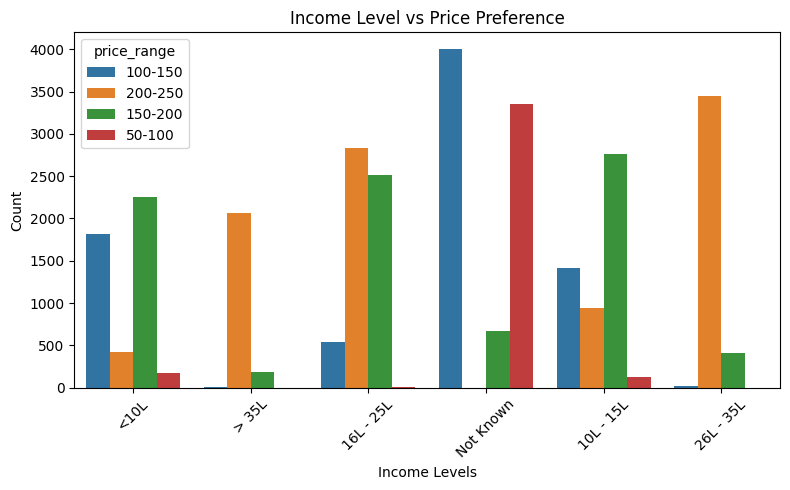

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))  # 👈 IMPORTANT (ensures proper save size)

sns.countplot(
    x='income_levels',
    hue='price_range',
    data=df_2
)

plt.xticks(rotation=45)
plt.title("Income Level vs Price Preference")
plt.xlabel("Income Levels")
plt.ylabel("Count")

plt.tight_layout()  # 👈 prevents label cutoff

plt.savefig("income_vs_price.png", dpi=300)  # 👈 save BEFORE show

plt.show()

<Figure size 1400x1000 with 0 Axes>

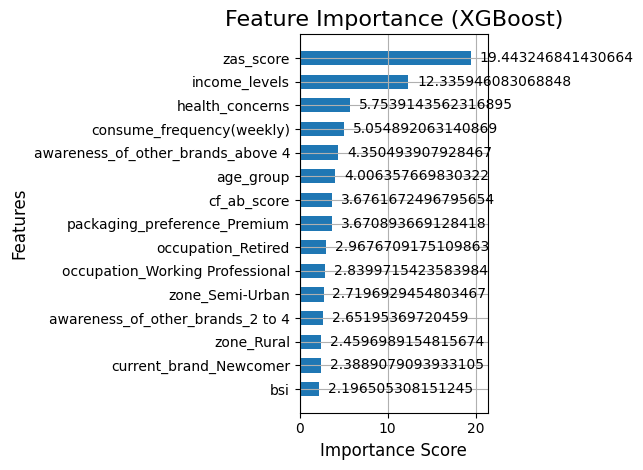

In [136]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(14,10))  

plot_importance(xgb_clf, importance_type='gain',max_num_features=15,height=0.6) 

plt.title("Feature Importance (XGBoost)", fontsize=16)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)

plt.show()

Customer pricing preference is mainly influenced by income level, consumption frequency, and lifestyle factors. Higher-income and frequent consumers tend to prefer premium pricing, while younger or less frequent users are more price-sensitive.”

In [123]:
df_2.groupby('income_levels')['price_range'].value_counts(normalize=True)

income_levels  price_range
10L - 15L      150-200        0.525805
               100-150        0.270044
               200-250        0.180156
               50-100         0.023995
16L - 25L      200-250        0.480753
               150-200        0.426827
               100-150        0.091063
               50-100         0.001357
26L - 35L      200-250        0.889205
               150-200        0.106147
               100-150        0.004649
<10L           150-200        0.484445
               100-150        0.389616
               200-250        0.089895
               50-100         0.036044
> 35L          200-250        0.918222
               150-200        0.080000
               100-150        0.001778
Not Known      100-150        0.498442
               50-100         0.417819
               150-200        0.083489
               200-250        0.000249
Name: proportion, dtype: float64

“From the analysis, income level is the most influential factor in determining price preference. High-income customers strongly prefer premium pricing, while mid and lower-income groups show increasing price sensitivity. This insight can help businesses design tiered pricing strategies for different customer segments.”

“The analysis shows that premium products are predominantly preferred by high-income customers, particularly those earning above ₹26 lakhs annually. These segments exhibit a strong willingness to pay higher prices. Meanwhile, upper-middle-income customers show potential for upselling, while lower-income groups remain price-sensitive.”

In [128]:
freq_price = df_2.groupby('consume_frequency(weekly)')['price_range'].value_counts(normalize=True).rename("proportion").reset_index()

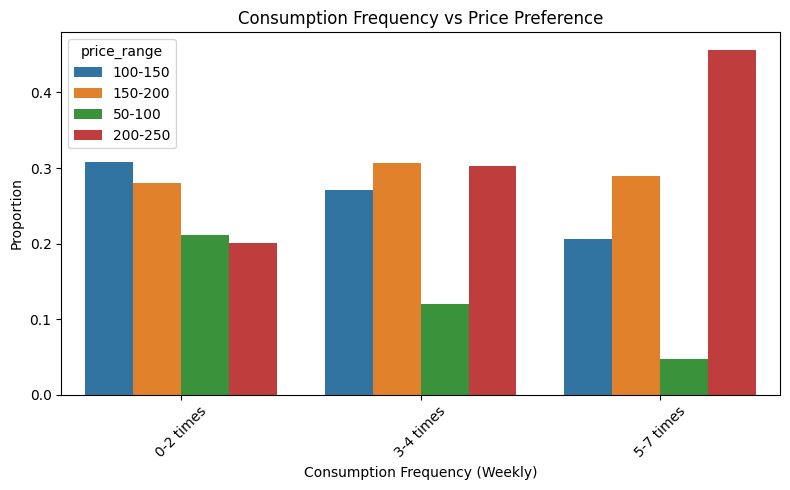

In [129]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=freq_price,
    x='consume_frequency(weekly)',
    y='proportion',
    hue='price_range'
)

plt.title("Consumption Frequency vs Price Preference")
plt.xlabel("Consumption Frequency (Weekly)")
plt.ylabel("Proportion")
plt.xticks(rotation=45)

plt.tight_layout()

# Save figure
plt.savefig("frequency_vs_price.png", dpi=300)

plt.show()

“As consumption frequency increases, the proportion of customers choosing higher price ranges also increases, indicating that frequent users are more willing to pay premium prices.”

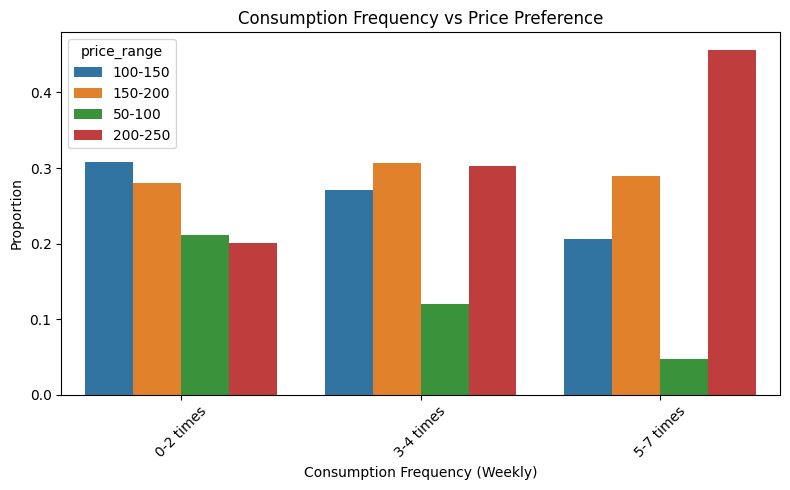

In [137]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=freq_price,
    x='consume_frequency(weekly)',
    y='proportion',
    hue='price_range'
)

plt.title("Consumption Frequency vs Price Preference")
plt.xlabel("Consumption Frequency (Weekly)")
plt.ylabel("Proportion")
plt.xticks(rotation=45)

plt.tight_layout()

# Save figure
plt.savefig("frequency_vs_price.png", dpi=300)

plt.show()

In [139]:
df['price_range'].value_counts(normalize=True)

price_range
200-250    0.323859
150-200    0.293802
100-150    0.260413
50-100     0.121926
Name: proportion, dtype: float64

In [140]:
pd.crosstab(df['income_levels'], df['consume_frequency(weekly)'], normalize='index')

consume_frequency(weekly),0-2 times,3-4 times,5-7 times
income_levels,,,
10L - 15L,0.280845,0.404227,0.314928
16L - 25L,0.283076,0.397256,0.319668
26L - 35L,0.206816,0.371030,0.422153
<10L,0.316252,0.389580,0.294168
> 35L,0.252777,0.393159,0.354065


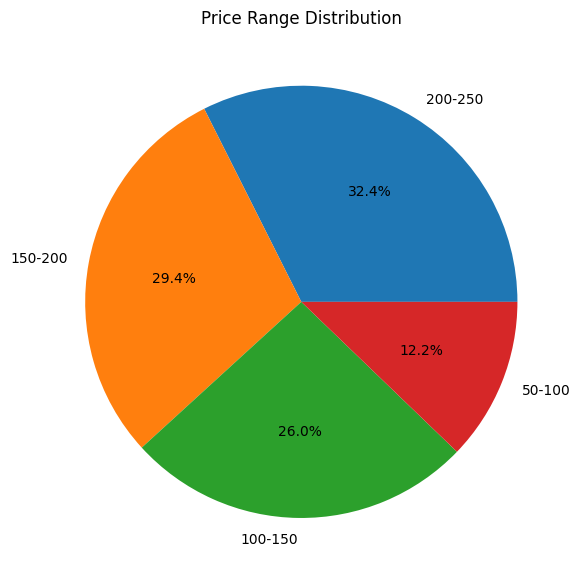

In [142]:
plt.figure(figsize=(6,6))
price_dist = df_2['price_range'].value_counts(normalize=True)
price_dist.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Price Range Distribution")
plt.ylabel("")

plt.tight_layout()

plt.savefig("price_distribution_pie.png", dpi=300)

plt.show()

In [149]:
df_2['income_levels'].value_counts()

income_levels
Not Known    8025
16L - 25L    5897
10L - 15L    5251
<10L         4661
26L - 35L    3872
> 35L        2250
Name: count, dtype: int64

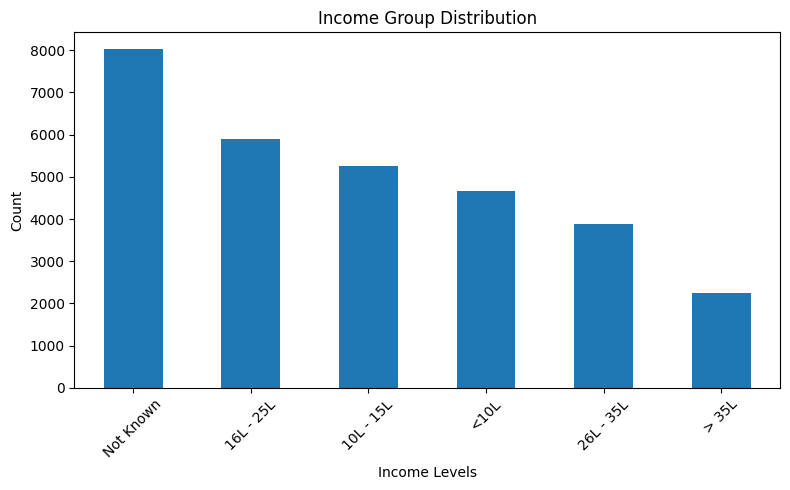

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df_2['income_levels'].value_counts().plot(kind='bar')

plt.title("Income Group Distribution")
plt.xlabel("Income Levels")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("income_distribution.png", dpi=300)

plt.show()

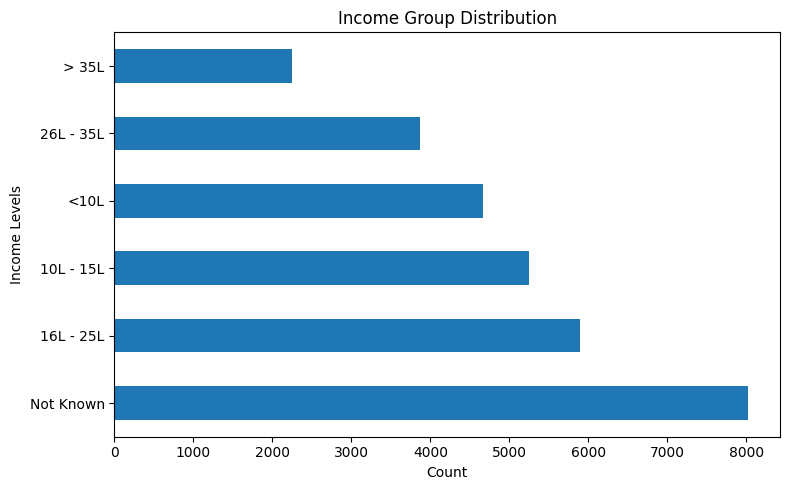

In [148]:
plt.figure(figsize=(8,5))

df_2['income_levels'].value_counts().plot(kind='barh')

plt.title("Income Group Distribution")
plt.xlabel("Count")
plt.ylabel("Income Levels")

plt.tight_layout()

plt.savefig("income_distribution.png", dpi=300)

plt.show()